# Completed section

In [ ]:
import math
import torch
import torch.nn as nn
import numpy as np
from torch.nn import functional as F
from einops import rearrange

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(device)

def norm(x: torch.Tensor) -> torch.Tensor:
    return F.rms_norm(x, (x.size(-1),))

def modulate(self, x, shift, scale): # for AdaLN. modulate(nn.LayerNorm())
    """
    x: (B, N, D)
    scale/shift: (B, D)
    """
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

class Patchify2D(nn.Module):
    def __init__(self, d_model: int, patch_size: int, color_channels: int):
        """
        input: (B, C, H, W)
        output: (B, N, D)
        """
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=color_channels, out_channels=d_model, kernel_size=patch_size, stride=patch_size
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # LINEAR CxHxW -> (H/p * W/p)xCPP -> (NxCPP) @ (CPP x d) -> NxD
        # CONV   CxHxW -> DxH/pxW/p       -> DxN -> NxD
        return rearrange(self.conv(x), "... d h w -> ...  (h w) d")
        

class Depatchify2D(nn.Module):
    def __init__(self, d_model: int, patch_size: int, color_channels: int, height: int, width: int):
        """
        input: (B, N, D)
        output: (B, C, H, W)
        """
        super().__init__()
        self.height = height
        self.width = width
        self.patch_size = patch_size
        
        self.deconv = nn.ConvTranspose2d(in_channels=d_model, out_channels=color_channels, kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h1 = self.height // self.patch_size
        w1 = self.width // self.patch_size
        # x # B, N, D -> B, H/p, W/p, D -> B, D, H/p, W/p
        # N = h // p * w // p
        x = rearrange(x, "... (h1 w1) d ->... d h1 w1", h1 = h1, w1 = w1)
        return self.deconv(x)
    
class FourierTimeEmbedding(nn.Module):
    def __init__(self, t_channels: int, w_min: float = 1.0, w_max: float = 10000.0):
        """
        input: (B)
        output: (B, T)
        """
        super().__init__()
        self.t_channels = t_channels
        half_dim = t_channels // 2
        
        w = w_min * ((w_max / w_min) ** ((torch.linspace(start=1, end=half_dim, steps=half_dim) - 1) / (half_dim - 1)))
        self.register_buffer("w", w) # non trainable

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        args = 2 * math.pi * torch.einsum('t, w -> tw', t, self.w)
        emb = math.sqrt(2.0 / self.t_channels) * torch.cat([torch.cos(args), torch.sin(args)], dim=1) # Batch x t_channels
        
        if self.t_channels % 2 == 1:  # zero pad
            emb = nn.functional.pad(emb, (0, 1), mode='constant')
        return emb
    
class MLP(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),      
            nn.Linear(out_channels, out_channels)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

cuda


## In prog

In [ ]:
class RoPE(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return NotImplementedError

In [ ]:
class DoubleStreamAttention(nn.Module): # TODO: RoPE 
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        
        self.n_heads = n_heads
        self.qkv_weights = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # -> qk norm -> concat -> attention
        qkv =  self.qkv_weights(x) # B, T, 3 * d_model
        q, k, v = rearrange(qkv, "b t (k nh hs) -> k b nh t hs", k=3, nh=self.n_heads).unbind(0)
        
        out = F.scaled_dot_product_attention(q, k, v)
        out = rearrange(out, 'b nh t hs -> b t (nh hs)')
        return self.proj(out)

In [ ]:
class AdaLN(nn.Module):
    def __init__(self, normalized_shape: int):
        """
        x: (B, N, D)
        scale/shift: (B, D)
        """
        super().__init__()
        self.ln = nn.LayerNorm(normalized_shape=normalized_shape)
    
    def forward(self, x: torch.Tensor, scale: torch.Tensor, shift: torch.Tensor) -> torch.Tensor:
        x = self.ln(x)
        return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

class mmDiTBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        """
        data (B, N, D)
        cond (B, T, D)
        time_steps (B, D)
        """
        super().__init__()
        
        self.adaln_mlp_text = nn.Sequential(nn.SiLU(), nn.Linear(d_model, 6 * d_model))
        self.adaln_mlp_image = nn.Sequential(nn.SiLU(), nn.Linear(d_model, 6 * d_model))
        for mlp in (self.adaln_mlp_text, self.adaln_mlp_image):
            nn.init.zeros_(mlp[1].weight)
            nn.init.zeros_(mlp[1].bias)
        
        self.adaln_text_1 = AdaLN(d_model)
        self.adaln_image_1 = AdaLN(d_model)
        
        self.double_stream_attn = DoubleStreamAttention(d_model, n_heads)
        
        self.adaln_text_2 = nn.Sequential(AdaLN(d_model), MLP(d_model, d_model))
        self.adaln_image_2 = nn.Sequential(AdaLN(d_model), MLP(d_model, d_model))
        
    def forward(self, data: torch.Tensor, cond: torch.Tensor, time_steps: torch.tensor):
        cond_text_scalars = rearrange(self.adaln_mlp_text(time_steps), "b (n d) -> b n d", n=6)
        cond_image_scalars = rearrange(self.adaln_mlp_image(time_steps), "b (n d) -> b n d", n=6)
        
        alpha_text, beta_text, gamma_text, delta_text, epsilon_text, zeta_text = cond_text_scalars.unbind(1)
        alpha_image, beta_image, gamma_image, delta_image, epsilon_image, zeta_image = cond_image_scalars.unbind(1)
    
        # (QKV)
        attn_text, attn_image = self.double_stream_attn(
            self.adaln_text_1(cond, alpha_text, beta_text),
            self.adaln_image_1(data, alpha_image, beta_image)
        )
        
        cond = gamma_text * attn_text + cond
        data = gamma_image * attn_image + data
        
        cond = zeta_text * self.adaln_text_2(cond, delta_text, epsilon_text) + cond
        data = zeta_image * self.adaln_image_2(data, delta_image, epsilon_image) + data
        
        return data, cond

Main Model

In [ ]:
class DiT(nn.Module):
    def __init__(self, d_model: int, patch_size: int, color_channels: int, height: int, width: int, t_channels: int, pooled_dim: int, t5_dim: int):
        """
        inputs:
        data (B, C, H, W)
        t5_cond (B, T, 512)
        
        time_steps (B)
        pooled_cond (B, 1280)
        """
        super().__init__()
        
        self.patchify = Patchify2D(d_model, patch_size, color_channels)
        self.depatchify = Depatchify2D(d_model, patch_size, color_channels, height, width)
        
        self.time_embed = nn.Sequential(
            FourierTimeEmbedding(t_channels),
            MLP(t_channels, d_model)
        )
        
        self.pooled_mlp = MLP(pooled_dim, d_model)
        self.t5_proj = nn.Linear(t5_dim, d_model)
        
        self.mmDiTBlocks = nn.ModuleList([self.mmDiTBlock(d_model) for _ in range(1)])
        
    def forward(self, data: torch.Tensor, t5_cond: torch.Tensor, time_steps: torch.Tensor, pooled_cond: torch.Tensor) -> torch.Tensor: # timesteps: torch.Tensor, condition: torch.Tensor)
        data = self.patchify(data)
        t5_cond = self.t5_proj(t5_cond)
        time_steps = self.time_embed(time_steps) + self.pooled_mlp(pooled_cond)
        
        for block in self.mmDiTBlocks:
            data, t5_cond = block(data, t5_cond, time_steps)
        
        
        return self.depatchify(data)

For testing purposes:

Don't import T5CLIP and load from the the save tensors.

In [3]:
data = torch.load("minidata/smallImageTensors.pt", weights_only=True).to(device) # pass through VAE
captions = np.load("minidata/smallCaptions.npy").tolist()
time_steps = torch.rand(data.size(0), device=device)

epsilon = torch.randn_like(data, device=device)
# t * z + (1 - t) * epsilon
interpolated = torch.einsum('b, b c h w -> b c h w', time_steps, data) + torch.einsum('b, b c h w -> b c h w', 1 - time_steps, epsilon)

In [4]:
debugging = True

if debugging is False:
    from T5CLIP import ConditioningEncoders

    T5CLIP = ConditioningEncoders(device=device, torch_dtype=torch.bfloat16)
    print(T5CLIP.pooled_dim, T5CLIP.t5_dim)

    t5, pooled = T5CLIP.encode(captions=captions)
else:
    t5clipdata = torch.load("minidata/t5clipsmall.pt", weights_only=True)
    t5 = t5clipdata['t5'].to(device)
    pooled = t5clipdata['pooled'].to(device)

In [5]:
model = DiT(
    d_model=256, 
    patch_size=2, 
    color_channels=3, 
    height=256, 
    width=256, 
    t_channels=32,
    pooled_dim=t5.shape[-1], # T5CLIP.pooled_dim,
    t5_dim=pooled.shape[-1] # T5CLIP.t5_dim
).to(device=device)


In [6]:
with torch.autocast(device_type=device, dtype=torch.bfloat16):
    output = model(interpolated, t5, time_steps, pooled)
    print(output.shape)

torch.Size([16, 3, 256, 256])


### random interpolation and image displaying

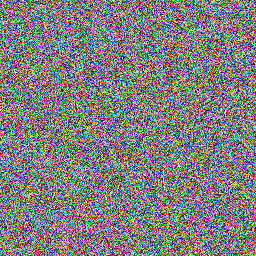

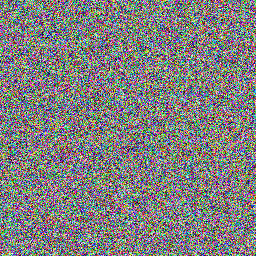

In [7]:
from torchvision.transforms import ToTensor, ToPILImage, transforms
from IPython.display import display
to_tensor = ToTensor()
to_image = ToPILImage()

display(to_image(output[2].float()))
display(to_image(interpolated[2].float()))

In [8]:
import matplotlib.pyplot as plt
from ipywidgets import interact, Layout, IntSlider

max_steps = 100
@torch.no_grad()
def show_image_interpolation(t, batch_idx):
    t = torch.tensor(t / max_steps, device=device)
    X_i = t.view(-1, 1, 1, 1) * data + (1 - t.view(-1, 1, 1, 1)) * epsilon
    X_i = rearrange(X_i[batch_idx], "c h w -> h w c").cpu()
    
    print(captions[batch_idx])
    plt.figure(figsize=(8, 8))
    plt.imshow(X_i) #, vmin=0, vmax=1)
    
interact(show_image_interpolation, t=IntSlider(min=0, max=(max_steps)), batch_idx=IntSlider(min=0, max=15), layout=Layout(width='75%'))

interactive(children=(IntSlider(value=0, description='t'), IntSlider(value=0, description='batch_idx', max=15)…

<function __main__.show_image_interpolation(t, batch_idx)>